# Week 1: Project Proposal and Data Selection/Preparation

## Olympic Games Analysis (1896-2016)

### Dataset Overview
Selected the **SportsStats Olympics Dataset** spanning 120 years of Olympic history for analysis.

### About SportsStats
SportsStats is a sports analysis firm that collaborates with:
- Local news organizations
- Elite personal trainers

Their goal is to provide compelling insights that can be used for:
- Developing news stories
- Discovering key health insights
- Identifying patterns and trends across groups, events, and countries

### Dataset Selection Rationale
This dataset was chosen for its:
- Comprehensive historical coverage
- Manageable file size
- Rich potential for meaningful analysis

## Initial Data Analysis and Cleanup

The Olympic dataset, available in CSV format, was imported into a Jupyter Notebook for preliminary analysis using Python. Initial data cleaning focused on:

1. **Data Quality Assessment**:
    - Total records: 271,116
    - Missing values identified:
      - Age: 9,474 missing entries
      - Height: 60,171 missing entries
      - Weight: 62,875 missing entries
    - Complete fields: Gender, Games, Year, Season, City

2. **Data Structure**:
    - Athlete information tracked through NOC (National Olympic Committee) codes
    - NOC codes preferred over team names due to historical name changes
    - Gender, competition details, and event information fully populated

This preliminary assessment provides a foundation for more detailed analysis while highlighting areas requiring data cleanup.

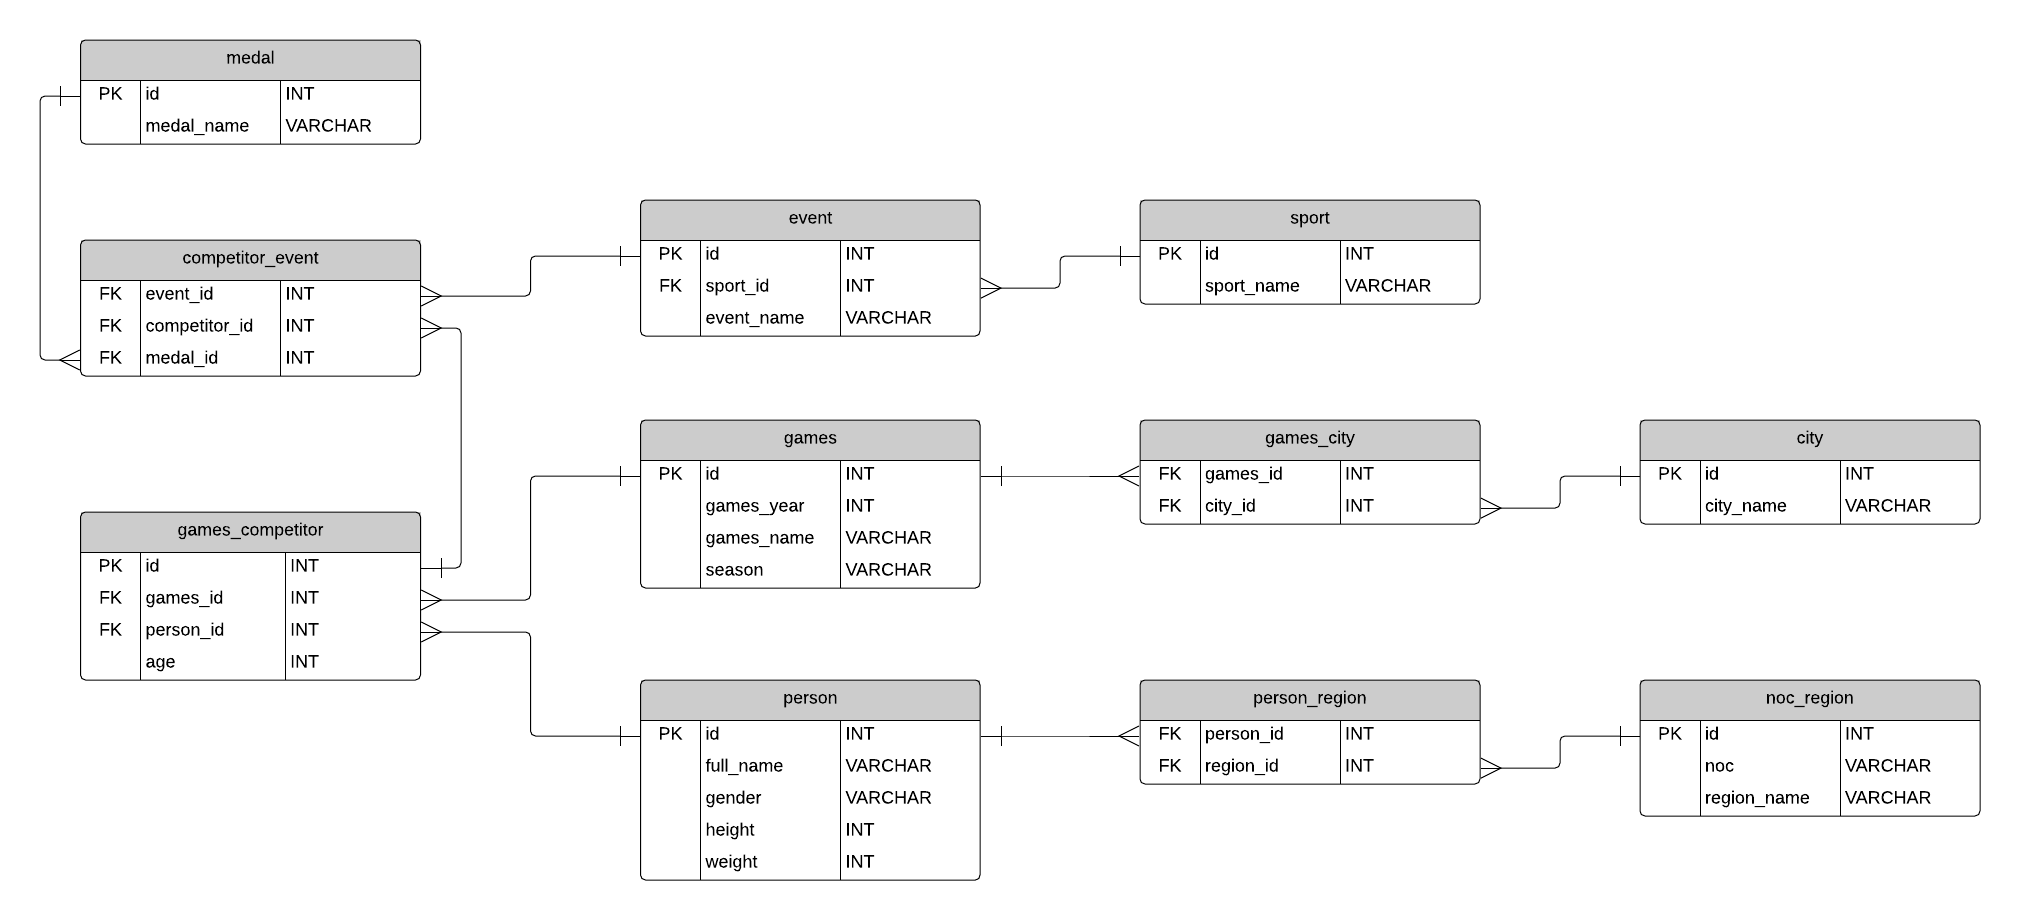

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [5]:
athelete_events_df = pd.read_csv("dataset/athlete_events.csv")
noc_regions_df = pd.read_csv("dataset/noc_regions.csv")

In [6]:
athelete_events_df

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,NaN
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,NaN
2,3,Gunnar Nielsen Aaby,M,24.0,NaN,NaN,Denmark,DEN,1920 Summer,1920,Summer,Antwerpen,Football,Football Men's Football,NaN
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold
4,5,Christine Jacoba Aaftink,F,21.0,185.0,82.0,Netherlands,NED,1988 Winter,1988,Winter,Calgary,Speed Skating,Speed Skating Women's 500 metres,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
271111,135569,Andrzej ya,M,29.0,179.0,89.0,Poland-1,POL,1976 Winter,1976,Winter,Innsbruck,Luge,Luge Mixed (Men)'s Doubles,NaN
271112,135570,Piotr ya,M,27.0,176.0,59.0,Poland,POL,2014 Winter,2014,Winter,Sochi,Ski Jumping,"Ski Jumping Men's Large Hill, Individual",NaN
271113,135570,Piotr ya,M,27.0,176.0,59.0,Poland,POL,2014 Winter,2014,Winter,Sochi,Ski Jumping,"Ski Jumping Men's Large Hill, Team",NaN
271114,135571,Tomasz Ireneusz ya,M,30.0,185.0,96.0,Poland,POL,1998 Winter,1998,Winter,Nagano,Bobsleigh,Bobsleigh Men's Four,NaN


In [16]:
noc_regions_df

,NOC,region,notes
0,AFG,Afghanistan,NaN
1,AHO,Curacao,Netherlands Antilles
2,ALB,Albania,NaN
3,ALG,Algeria,NaN
4,AND,Andorra,NaN
...,...,...,...
225,YEM,Yemen,NaN
226,YMD,Yemen,South Yemen
227,YUG,Serbia,Yugoslavia
228,ZAM,Zambia,NaN


In [18]:
#Stats of atheletes divided by sex
grouped = athelete_events_df.groupby(athelete_events_df["Sex"])
print("Male athletes")
print(grouped.get_group("M").nunique())
print("---")
print("Female athletes")
print(grouped.get_group("F").nunique())

Male athletes
ID        101590
Name      100979
Sex            1
Age           74
Height        92
Weight       206
Team        1154
NOC          230
Games         51
Year          35
Season         2
City          42
Sport         63
Event        554
Medal          3
dtype: int64
---
Female athletes
ID        33981
Name      33808
Sex           1
Age          62
Height       77
Weight      140
Team        374
NOC         222
Games        50
Year         34
Season        2
City         42
Sport        53
Event       269
Medal         3
dtype: int64


In [20]:
athelete_events_df.isna().sum().sum()

363853

In [ ]:
gender_df = athelete_events_df.drop(
    ["ID", "Name", "Age", "Height", "Weight", "Team", "NOC", "Games", "Year", "Season", "City", "Sport", "Event"], axis='columns')
gender_df = gender_df.dropna()
gender_df

,Sex,Medal
3,M,Gold
37,M,Bronze
38,M,Bronze
40,M,Bronze
41,M,Bronze
...,...,...
271078,F,Silver
271080,F,Bronze
271082,M,Bronze
271102,F,Bronze


In [21]:
#Number of unique atheletes by gender
gender_df.groupby("Sex").count()

,Medal
Sex,
F,11253
M,28530


In [22]:
gender_df.groupby("Medal").count()

,Sex
Medal,
Bronze,13295
Gold,13372
Silver,13116


In [ ]:
#Stats of each team
athelete_events_df.groupby("Team").count()

,ID,Name,Sex,Age,Height,Weight,NOC,Games,Year,Season,City,Sport,Event,Medal
Team,,,,,,,,,,,,,,
30. Februar,2,2,2,2,2,1,2,2,2,2,2,2,2,0
A North American Team,4,4,4,3,0,0,4,4,4,4,4,4,4,4
Acipactli,3,3,3,3,3,3,3,3,3,3,3,3,3,0
Acturus,2,2,2,1,0,0,2,2,2,2,2,2,2,0
Afghanistan,126,126,126,78,54,61,126,126,126,126,126,126,126,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Zambia,183,183,183,154,128,139,183,183,183,183,183,183,183,2
Zefyros,2,2,2,2,2,2,2,2,2,2,2,2,2,0
Zimbabwe,309,309,309,307,286,287,309,309,309,309,309,309,309,22


In [ ]:
#Differences between Summer and Winter games.

athelete_events_df.groupby("Season").count()

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,City,Sport,Event,Medal
Season,,,,,,,,,,,,,,
Summer,222552,222552,222552,213363,170695,168698,222552,222552,222552,222552,222552,222552,222552,34088
Winter,48564,48564,48564,48279,40250,39543,48564,48564,48564,48564,48564,48564,48564,5695


In [15]:
grouped = athelete_events_df.groupby(athelete_events_df["Season"])
print("Summer games")
print(grouped.get_group("Summer").nunique())
print("---")
print("Winter games")
print(grouped.get_group("Winter").nunique())


Summer games
ID        116776
Name      116122
Sex            2
Age           74
Height        95
Weight       219
Team        1157
NOC          230
Games         29
Year          29
Season         1
City          23
Sport         52
Event        651
Medal          3
dtype: int64
---
Winter games
ID        18958
Name      18923
Sex           2
Age          47
Height       64
Weight      125
Team        221
NOC         119
Games        22
Year         22
Season        1
City         19
Sport        17
Event       119
Medal         3
dtype: int64
